In [1]:

import numpy as np
import matplotlib, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, Polygon, FancyArrowPatch, Arc
import warnings; warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white','axes.edgecolor':'#333333',
    'text.color':'#333333','axes.labelcolor':'#333333','xtick.color':'#333333',
    'ytick.color':'#333333','font.family':'sans-serif','font.size':9.5,
    'axes.titlesize':11,'axes.spines.top':False,'axes.spines.right':False,
})
BLUE,ORANGE,GREEN,GOLD,LBLUE,PINK,GRAY = (
    '#0072B2','#D55E00','#009E73','#E69F00','#56B4E9','#CC79A7','#888888')


# 5.1 — Fixed-wing aircraft configurations

> *Configuration is not a stylistic choice. It determines what the aircraft can do, how it handles,
> how much it costs to build, and in many cases whether it survives a mistake.*

The first sketch on a blank sheet — the decision to put the wing on top or bottom of the fuselage,
to use a T-tail or a V-tail, to fly without a tail at all — sets constraints that stay until the
aircraft is retired. Aerodynamicists, structures engineers, and pilots all live with this choice.
Getting it right requires understanding not just the academic pros and cons, but the *operating
context*: a configuration that works perfectly for a 600-passenger airliner may be completely wrong
for a 600-gram FPV racer.

This notebook covers every major fixed-wing configuration in detail, with separate analysis for
full-scale aircraft and RC/UAV platforms. The two contexts differ more than most textbooks
acknowledge: full-scale designs are dominated by structural efficiency, certification, and passenger
comfort; RC designs are dominated by build simplicity, CG sensitivity, and what can actually be
bought at a hobby shop. The same configuration can be the obvious choice in one context and a
genuine liability in the other.

**Topics covered:**

- Fuselage layout (conventional, pod-and-boom, twin-boom, slab-sided)
- Wing position (high, mid, low, shoulder/parasol)
- Wing planform and taper: rectangular, aft-tapered, elliptical, swept back, forward swept, delta
- Tail configurations: conventional, T-tail, V-tail, H-tail, cruciform, triple tail
- Canard and three-surface layouts
- Flying wing and blended wing-body (BWB)

```{seealso}
{doc}`../02_Requirements/04_mission_profiles` — the mission profile constrains which
configurations are viable before any aerodynamic analysis begins.
{doc}`05_trade_studies` — Pugh matrix and weighted decision tools for choosing between configurations.
```


## 1 — Fuselage configurations

The fuselage does three things: it carries the payload, it provides the moment arm for the tail
surfaces, and its wetted area drives a significant fraction of total profile drag. Those three
requirements pull in different directions. A short, fat fuselage minimises structural weight for a
given internal volume but produces more drag and shortens the tail arm. A long, slender fuselage
reduces drag and improves stability but is heavier and harder to build.

Four broad configurations dominate practical fixed-wing design.


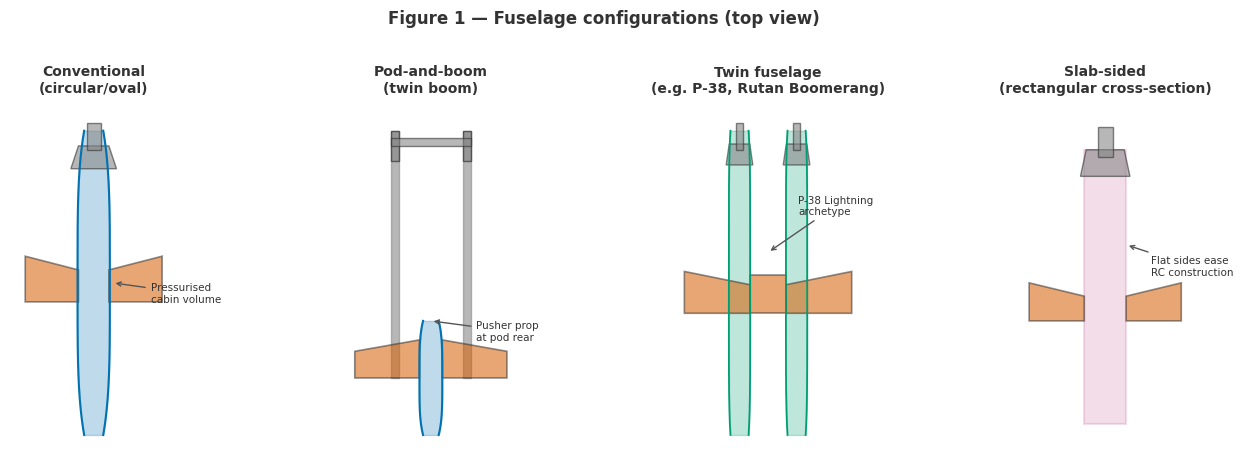

Figure 1 OK


In [2]:

# ── Figure 1: Fuselage configuration schematics (top view) ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
fig.suptitle('Figure 1 — Fuselage configurations (top view)', fontsize=12, fontweight='bold', y=1.02)

def draw_conventional(ax):
    # Fuselage: tapered oval top-view
    from matplotlib.patches import FancyBboxPatch
    xs = np.linspace(0, 8, 200)
    w_half = 0.5 * (1 - ((xs-4)/5)**4) * 0.85
    ax.fill_betweenx(xs, -w_half, w_half, color=BLUE, alpha=0.25, label='fuselage')
    ax.plot(-w_half, xs, color=BLUE, lw=1.5)
    ax.plot(w_half,  xs, color=BLUE, lw=1.5)
    # Wing (mid-position)
    wchord = 1.2
    ax.fill_between([3.2, 4.4], [-1.8, -0.8], [-1.8, -0.8], color=ORANGE, alpha=0.0)
    # Left wing
    wx = [-1.8, -0.4, -0.4, -1.8]
    wy = [3.5,  3.5,  3.5+wchord*0.7, 3.5+wchord]
    ax.fill(wx, wy, color=ORANGE, alpha=0.55, edgecolor='#333', lw=1.2)
    # Right wing
    ax.fill([-x for x in wx], wy, color=ORANGE, alpha=0.55, edgecolor='#333', lw=1.2)
    # Tail surfaces
    ax.fill([-0.6, 0.6, 0.4, -0.4], [7.0, 7.0, 7.6, 7.6], color=GRAY, alpha=0.6, edgecolor='#333', lw=1)
    ax.fill([-0.18, 0.18, 0.18, -0.18], [7.5, 7.5, 8.2, 8.2], color=GRAY, alpha=0.6, edgecolor='#333', lw=1)
    ax.set_title('Conventional\n(circular/oval)', fontsize=10, fontweight='bold')
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-0.5, 8.8)
    ax.set_aspect('equal'); ax.axis('off')
    # Annotations
    ax.annotate('Pressurised\ncabin volume', xy=(0.5, 4.0), xytext=(1.5, 3.5),
                fontsize=7.5, arrowprops=dict(arrowstyle='->', color='#555'), color='#333')

def draw_pod_boom(ax):
    # Central pod
    pod_xs = np.linspace(0, 3, 100)
    pw = 0.5 * (1 - ((pod_xs-1.5)/2)**4) * 0.6
    ax.fill_betweenx(pod_xs, -pw, pw, color=BLUE, alpha=0.25)
    ax.plot(-pw, pod_xs, color=BLUE, lw=1.5); ax.plot(pw, pod_xs, color=BLUE, lw=1.5)
    # Booms (twin)
    for sign in [-1, 1]:
        bx = sign * 0.95
        ax.fill_betweenx(np.linspace(1.5, 8.0, 50),
                         np.full(50, bx-0.1), np.full(50, bx+0.1),
                         color=GRAY, alpha=0.6)
    # Wing (on pod)
    wx = [-2.0, -0.3, -0.3, -2.0]
    wy = [1.5, 1.5, 1.5+1.0, 1.5+0.7]
    ax.fill(wx, wy, color=ORANGE, alpha=0.55, edgecolor='#333', lw=1.2)
    ax.fill([-x for x in wx], wy, color=ORANGE, alpha=0.55, edgecolor='#333', lw=1.2)
    # Tail (H-tail connecting booms)
    for sign in [-1, 1]:
        bx = sign * 0.95
        # Fin
        ax.fill([bx-0.1, bx+0.1, bx+0.1, bx-0.1], [7.2, 7.2, 8.0, 8.0],
                color=GRAY, alpha=0.7, edgecolor='#333', lw=1)
    # Horizontal stab connecting booms
    ax.fill([-1.05, 1.05, 1.05, -1.05], [7.6, 7.6, 7.8, 7.8],
            color=GRAY, alpha=0.6, edgecolor='#333', lw=1)
    ax.annotate('Pusher prop\nat pod rear', xy=(0, 3.0), xytext=(1.2, 2.5),
                fontsize=7.5, arrowprops=dict(arrowstyle='->', color='#555'), color='#333')
    ax.set_title('Pod-and-boom\n(twin boom)', fontsize=10, fontweight='bold')
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-0.5, 8.8)
    ax.set_aspect('equal'); ax.axis('off')

def draw_twin_fus(ax):
    # Twin fuselages
    for sign in [-1, 1]:
        cx = sign * 0.75
        xs2 = np.linspace(0, 8, 200)
        w2 = 0.28 * (1 - ((xs2-4)/5.5)**6)
        ax.fill_betweenx(xs2, np.full(200,cx)-w2, np.full(200,cx)+w2,
                         color=GREEN, alpha=0.25)
        ax.plot(np.full(200,cx)-w2, xs2, color=GREEN, lw=1.3)
        ax.plot(np.full(200,cx)+w2, xs2, color=GREEN, lw=1.3)
    # Wing across both fuselages
    for sign in [-1, 1]:
        wx2 = [sign*0.47, sign*2.2, sign*2.2, sign*0.47]
        wy2 = [3.2, 3.2, 3.2+1.1, 3.2+0.75]
        ax.fill(wx2, wy2, color=ORANGE, alpha=0.55, edgecolor='#333', lw=1.2)
    # Centre section of wing
    ax.fill([-0.47, 0.47, 0.47, -0.47], [3.2, 3.2, 3.2+1.0, 3.2+1.0],
            color=ORANGE, alpha=0.55, edgecolor='#333', lw=1.2)
    # Tails on each fuselage
    for sign in [-1, 1]:
        cx = sign * 0.75
        ax.fill([cx-0.35, cx+0.35, cx+0.27, cx-0.27], [7.1, 7.1, 7.65, 7.65],
                color=GRAY, alpha=0.6, edgecolor='#333', lw=1)
        ax.fill([cx-0.1, cx+0.1, cx+0.1, cx-0.1], [7.5, 7.5, 8.2, 8.2],
                color=GRAY, alpha=0.6, edgecolor='#333', lw=1)
    ax.annotate('P-38 Lightning\narchetype', xy=(0, 4.8), xytext=(0.8, 5.8),
                fontsize=7.5, arrowprops=dict(arrowstyle='->', color='#555'), color='#333',
                ha='left')
    ax.set_title('Twin fuselage\n(e.g. P-38, Rutan Boomerang)', fontsize=10, fontweight='bold')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-0.5, 8.8)
    ax.set_aspect('equal'); ax.axis('off')

def draw_slab(ax):
    # Slab-sided rectangular fuselage
    ax.fill([-0.55, 0.55, 0.55, -0.55], [0.3, 0.3, 7.5, 7.5],
            color=PINK, alpha=0.25, edgecolor=PINK, lw=1.5)
    # Wing
    for sign in [-1, 1]:
        wx3 = [sign*0.55, sign*2.0, sign*2.0, sign*0.55]
        wy3 = [3.0, 3.0, 3.0+1.0, 3.0+0.65]
        ax.fill(wx3, wy3, color=ORANGE, alpha=0.55, edgecolor='#333', lw=1.2)
    # Tail
    ax.fill([-0.65, 0.65, 0.5, -0.5], [6.8, 6.8, 7.5, 7.5],
            color=GRAY, alpha=0.6, edgecolor='#333', lw=1)
    ax.fill([-0.2, 0.2, 0.2, -0.2], [7.3, 7.3, 8.1, 8.1],
            color=GRAY, alpha=0.6, edgecolor='#333', lw=1)
    ax.annotate('Flat sides ease\nRC construction', xy=(0.55, 5.0), xytext=(1.2, 4.2),
                fontsize=7.5, arrowprops=dict(arrowstyle='->', color='#555'), color='#333')
    ax.set_title('Slab-sided\n(rectangular cross-section)', fontsize=10, fontweight='bold')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-0.5, 8.8)
    ax.set_aspect('equal'); ax.axis('off')

draw_conventional(axes[0])
draw_pod_boom(axes[1])
draw_twin_fus(axes[2])
draw_slab(axes[3])

plt.tight_layout()
plt.savefig('fig1_fuselage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 OK")


### Conventional (circular or oval cross-section)

Every pressurised transport aircraft — from the Douglas DC-3 onward — uses a circular or near-
circular fuselage cross-section, and for a simple reason: a pressure vessel that must withstand
repeated cycles of 8–9 psi differential pressure distributes hoop stress uniformly only in a
circle {cite}`raymer2018`. An oval cross-section is a compromise: it gives more headroom without
going full double-bubble (as in the 787), but it requires heavier local reinforcement wherever the
curvature breaks.

**Full-scale advantages.** Circular fuselages are structurally efficient under pressurisation. The
frame-and-stringer semi-monocoque construction standard since the 1950s produces an excellent
strength-to-weight ratio. Circular sections also integrate cleanly with circular frames, which
simplifies jig and tooling design for high-rate production.

**Full-scale disadvantages.** A circular fuselage has high wetted area for a given usable internal
volume. The fuselage of a typical airliner contributes roughly 30–40% of total aircraft zero-lift
drag. There is also a fundamental conflict between the ideal aerodynamic shape (a body of revolution
with a fineness ratio around 10:1) and the ideal structural shape (short, thick cylinder) —
airliners sit somewhere in the middle and pay a penalty in both.

**RC advantages.** Circular fibreglass or carbon-fibre tube fuselages are light, stiff, and easy
to source. They transmit torque well, which matters for models that land tail-first in a spin or
take high torsional loads from a rough landing. Most foam-and-film trainer designs use either a
slab or an approximate oval, but sport and scale models routinely use formed fibreglass.

**RC disadvantages.** Internal access is poor once the fuselage is closed — any component buried
behind the wing former requires significant disassembly. Mounting hatches weaken the structure at
the worst location (tension and bending in the belly) unless carefully reinforced.

---

### Pod-and-boom

A central pod, usually housing the motor, payload, and electronics, is attached to one or two
slender booms carrying the tail surfaces. The Reims Cessna 337 Skymaster, the Lockheed P-38
Lightning (in its original single-boom form), and virtually every modern UAV from the Predator to
the DJI Phantom use some variant of this layout.

**Full-scale advantages.** The pusher configuration — engine at the rear of the pod — clears the
forward hemisphere for sensors, eliminates propwash over the cabin windows, and reduces cabin
noise significantly. For ISR and surveillance aircraft this matters enormously: a turboprop pushing
from the rear (as on the Predator) keeps the forward-looking sensor payload in clean, uninterrupted
air {cite}`sadraey2012`.

**Full-scale disadvantages.** The boom is a long, slender beam subject to flutter. Boom fatigue
has been a recurring issue on UAV platforms. The single-engine pusher also concentrates the engine
weight at the rear of the pod, which moves the CG aft and tightens the acceptable CG range.
Crashworthiness is poor: in a nose-down crash, the boom and tail structure provide no energy
absorption for the payload pod.

**RC advantages.** This layout dominates FPV freestyle and long-range fixed-wing UAV design for a
reason: the carbon-fibre boom is light, stiff, easily replaced after a crash, and the pusher motor
keeps the camera unobstructed. Many long-range FPV designs (Matek wing, ZOHD Dart, Volantex
Ranger) are essentially pod-and-boom. Replacing a snapped boom costs a few pounds; replacing a
crashed conventional fuselage may require rebuilding half the aircraft.

**RC disadvantages.** Boom vibration from the pusher motor propagates directly to the tail
surfaces. At high RPM this can excite resonant frequencies in carbon booms and cause servo wear or
even structural failure. Securing the boom to the pod requires a strong joint at exactly the point
where bending moment is highest.

---

### Twin fuselage

Two fuselages side-by-side, connected by a common wing centre section. This configuration appears
at the extremes: very large payload carriers (where a single fuselage would be impractically wide)
and some high-performance piston fighters (P-38, de Havilland Hornet). Rutan's Boomerang used a
deliberate asymmetric twin-fuselage layout to solve a specific asymmetric thrust problem.

**Full-scale advantages.** The twin fuselage doubles internal volume without doubling wetted area
(the common wing and shared centre section don't count twice). For strategic airlifters or special-
mission aircraft, this can be the only way to carry an outsized payload without an impossibly tall
single fuselage. Engine placement in each fuselage also gives natural redundancy.

**Full-scale disadvantages.** The structural junction between wing, fuselage, and the connecting
centre section is extremely complex. CG travel with loading is difficult to control — filling one
fuselage but not the other can shift the lateral CG, generating a rolling tendency. This
configuration has no current civil application outside experimental aircraft.

**RC advantages.** Almost none in practice. The twin-fuselage layout requires significantly more
build complexity than any competing configuration for the same span, without offering a clear
aerodynamic or payload benefit at RC scale.

**RC disadvantages.** Two fuselages mean two servos for rudder, more wiring, more weight, and a
substantially harder build. It remains a novelty or scale-replica choice (P-38 models).

---

### Slab-sided (rectangular cross-section)

A fuselage with flat sides and a flat bottom — the rectangular box. No aircraft designer uses this
for aerodynamic reasons. It appears because flat panels are easy to cut, sand, and cover; joining
flat faces is faster than joining curved ones; and many basic RC kits have used slab-sided
construction since the 1950s.

**Full-scale:** Used in unpressurised utility aircraft where construction simplicity and repairability
matter (STOL bush aircraft, agricultural sprayers, some military trainers). The Fieseler Storch had
a slab-sided fuselage built from welded steel tube with fabric covering — repaired in the field
with wire and patches. At transport category speeds and altitudes, the aerodynamic penalty and the
structural inefficiency under pressurisation rule it out entirely.

**RC advantages.** A slab-sided fuselage can be built from flat foam sheet or balsa plywood in an
afternoon. Every surface is flat and easy to align. Hatches cut flush with the sides. Most trainer
designs aimed at beginners use this approach precisely because a nervous new builder can complete
it without curves or jigs.

**RC disadvantages.** The square edges produce significantly more profile drag than a rounded
fuselage of the same cross-sectional area. At typical RC flight speeds (15–30 m/s) this is
measurable — an equivalent circular fuselage might have 30–50% less form drag. For anything other
than a slow trainer, the aerodynamic cost is not worth the build simplicity.

```{cite}`raymer2018,sadraey2012,torenbeek2013`


## 2 — Wing vertical position

Where the wing sits on the fuselage — high, mid, or low — shapes almost every downstream decision.
The wing carry-through structure, the landing gear, the fuel volume, and the ground clearance for
engines and propellers all depend on this single choice. There is no objectively correct answer,
only the right answer for the mission.


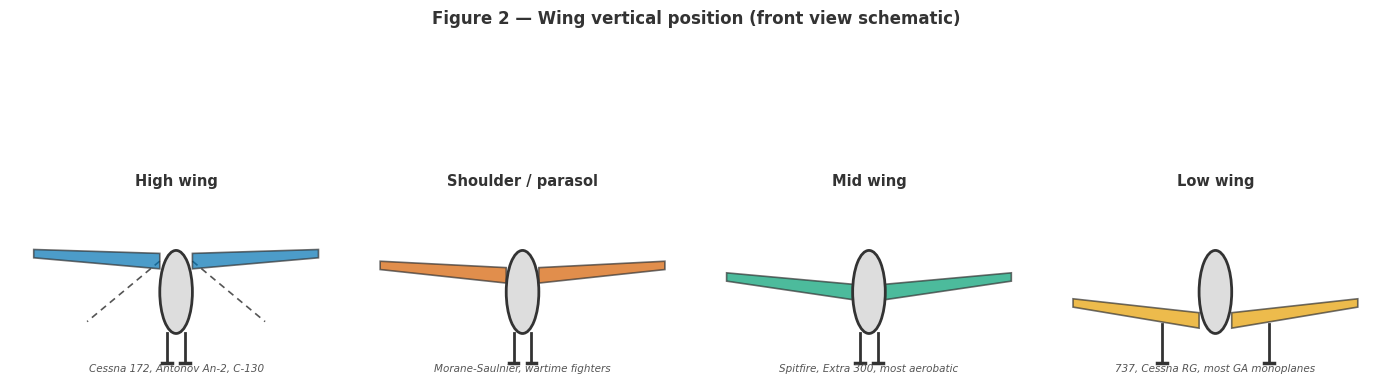

Figure 2 OK


In [3]:

# ── Figure 2: Wing position — front view ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle('Figure 2 — Wing vertical position (front view schematic)', fontsize=12,
             fontweight='bold', y=1.02)

def wing_front_view(ax, name, yw, color, struts=False, gear_from_wing=False,
                    dihedral_deg=5.0, note=''):
    ax.set_xlim(-2.8, 2.8); ax.set_ylim(-1.4, 1.6)
    ax.set_aspect('equal'); ax.axis('off')

    # Fuselage (vertical ellipse)
    fus = Ellipse((0, 0), 0.55, 1.4, facecolor='#DDDDDD',
                  edgecolor='#333333', linewidth=2, zorder=4)
    ax.add_patch(fus)

    # Wing half-span = 2.4; dihedral
    span_half = 2.4
    dih = np.tan(np.radians(dihedral_deg)) * span_half
    root_chord_h = 0.13
    tip_chord_h  = 0.07
    root_x = 0.275  # fuselage half-width at wing station

    for sign in [-1, 1]:
        tip_y = yw + sign * 0  # mirror across centreline — sign on x
        xs = np.array([sign*root_x, sign*span_half])
        ys_low = np.array([yw - root_chord_h, yw - tip_chord_h + dih])
        ys_hi  = np.array([yw + root_chord_h, yw + tip_chord_h + dih])
        ax.fill(np.append(xs, xs[::-1]),
                np.append(ys_low, ys_hi[::-1]),
                color=color, alpha=0.70, edgecolor='#333333', linewidth=1.2, zorder=3)

    # Optional struts (high-wing bracing)
    if struts:
        for sign in [-1, 1]:
            ax.plot([sign*0.275, sign*1.5], [yw, -0.5], '--',
                    color='#555555', linewidth=1.2, zorder=2, dashes=(4,3))

    # Landing gear
    if gear_from_wing:
        for sign in [-1, 1]:
            ax.plot([sign*0.9, sign*0.9], [yw - root_chord_h*0.5, -1.2],
                    color='#333333', linewidth=2.0, zorder=2)
            ax.plot([sign*0.9-0.08, sign*0.9+0.08], [-1.2, -1.2],
                    color='#333333', linewidth=2.5, zorder=2)
    else:
        for sign in [-1, 1]:
            ax.plot([sign*0.15, sign*0.15], [-0.7, -1.2],
                    color='#333333', linewidth=2.0, zorder=2)
            ax.plot([sign*0.15-0.08, sign*0.15+0.08], [-1.2, -1.2],
                    color='#333333', linewidth=2.5, zorder=2)

    ax.set_title(name, fontsize=10.5, fontweight='bold', pad=8)
    if note:
        ax.text(0, -1.35, note, ha='center', fontsize=7.5, color='#555', style='italic')

wing_front_view(axes[0], 'High wing', 0.52, BLUE, struts=True, dihedral_deg=3,
                note='Cessna 172, Antonov An-2, C-130')
wing_front_view(axes[1], 'Shoulder / parasol', 0.28, ORANGE, dihedral_deg=4,
                note='Morane-Saulnier, wartime fighters')
wing_front_view(axes[2], 'Mid wing', 0.0, GREEN, dihedral_deg=6,
                note='Spitfire, Extra 300, most aerobatic')
wing_front_view(axes[3], 'Low wing', -0.48, GOLD, gear_from_wing=True, dihedral_deg=7,
                note='737, Cessna RG, most GA monoplanes')

plt.tight_layout()
plt.savefig('fig2_wing_position.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 OK")


### High wing

The wing sits on top of the fuselage. Classic examples: Cessna 172, de Havilland DHC-6 Twin
Otter, C-130 Hercules, Antonov An-2.

**Full-scale advantages.** The fuselage sits low to the ground, which matters enormously for cargo
loading — the floor of a C-130 is 1.3 m above the ground without a loading ramp, roughly half
what a comparable low-wing freighter would need {cite}`raymer2018`. Ground clearance for large-
diameter propellers or underwing pods is achieved without requiring a tall undercarriage. The
pendulum stability effect — the CG hanging below the wing's aerodynamic centre — gives a natural
rolling restoring moment, making the aircraft inherently resistant to uncommanded roll upsets. High-
wing aircraft generally require less dihedral than low-wing aircraft to achieve equivalent lateral
stability.

**Full-scale disadvantages.** The wing carry-through structure must pass over the top of the
fuselage cabin, which either intrudes into headroom (most GA types solve this with a window
blister) or forces a fuselage deep-section penalty. Landing gear must be long enough to provide
ground clearance for the engine nacelles, or must be mounted to the fuselage — the latter requiring
a wide fuselage to give adequate track. On transport aircraft this drives fuselage and gear weight
upward. Braced struts (used on most single-engine high-wings to allow a thin wing) add profile
drag.

**RC advantages.** High-wing aircraft are the standard trainer configuration for a strong reason:
they are inherently self-levelling. A new pilot who releases the transmitter will usually see the
model return to wings-level on its own. Ground handling is straightforward — the low fuselage
allows a simple flat undercarriage with no nose-over tendency. The wing provides a direct view
of the ground from directly below the fuselage, useful for judging landings on grass strips.

**RC disadvantages.** The self-levelling tendency that makes high-wing aircraft forgiving for
beginners makes them sluggish in roll for sport flying. You can increase roll rate with dihedral
reduction, but you then lose the stability advantage. High-wing designs also need some mechanism
to attach the wing to the top of the fuselage: a saddle, dowels, or bolts — all of which add
complication compared to a low-wing's wing-in-fuselage mounting.

---

### Mid wing

The wing passes through the middle of the fuselage. The Supermarine Spitfire, the Extra 300, and
virtually all purpose-designed aerobatic aircraft use mid-wing layouts.

**Full-scale advantages.** Interference drag between wing and fuselage is lowest at mid-position
because the airflow approaching the junction has less curvature around either surface. Roll rate is
generally highest of the three configurations for a given wing design. There are no stability biases
imposed by geometry: the aerobatic pilot gets a neutral-feeling aircraft that responds symmetrically
to inputs in both directions {cite}`sadraey2012`.

**Full-scale disadvantages.** The wing spar must pass through the fuselage, which in a cabin
aircraft divides the interior at exactly the point where passengers or payload need continuous
space. Every commercial aircraft that uses a mid-wing layout — there are almost none — deals with
this by designing a specific structural pass-through that interrupts the cabin floor. The Fokker
F100 and some military transports accept the intrusion; most airliners do not. The wing-fuselage
fairing also requires more careful design to avoid separation at the root junction.

**RC advantages.** For aerobatic and fast-flying RC aircraft, mid wing is the right answer. The
aircraft behaves the same inverted as upright. Rolls are fast and precise. Many ARF
(almost-ready-to-fly) aerobatic models from 60-cm Extras to 2-m pitts biplanes use mid-wing
layouts, and they fly predictably because of it.

**RC disadvantages.** The wing spar channel cuts the fuselage in half, which complicates battery
access, servo routing, and any payload installation. For a model that needs easy access to
electronics, this is a genuine nuisance. Ground clearance is also moderate — landing in long grass
risks prop strikes without adequate undercarriage height.

---

### Low wing

The wing is attached at the bottom of the fuselage. The Boeing 737, most modern airliners, and
the majority of GA retractable singles (Cessna 210, Piper PA-28) use this layout.

**Full-scale advantages.** The main undercarriage legs can retract directly into the wing box,
keeping them short and therefore light. This one fact explains why virtually all airliners are
low-wing: short gear means lighter gear, and heavy landing gear appears as fixed weight in the
payload budget. The full cabin cross-section is uninterrupted from door to door. Wing-in-ground
effect during landing is strong, giving a natural flare cue that pilots find intuitive.

**Full-scale disadvantages.** A low wing requires more dihedral to achieve the same lateral
stability as a high wing of identical geometry, because the CG is now *above* the aerodynamic
centre of the wing rather than below it — the geometry works against stability. Engine nacelles
mounted below the wing may ingest debris from unpaved runways. Ground clearance for propellers on
turboprops (ATR 72, Dash 8) requires either large-diameter undercarriage or careful positioning of
the engine along the leading edge.

**RC advantages.** Low-wing RC aircraft are the standard for scale replication of airliners, warbirds,
and modern GA aircraft. They look right, which matters to a scale builder. The undercarriage can be
scaled accurately, with main gear retracting into the wing. Low-wing trainers like the Piper
Cub-style designs give beginner pilots a slightly more challenging and rewarding experience than
high-wing equivalents, and many argue the transition to real aircraft handling is smoother.

**RC disadvantages.** Low-wing aircraft tip over on rough ground far more easily than high-wing
designs. The props are close to the ground — one bounce landing and the prop strikes. Roll is
faster and the aircraft is less inherently stable, which is fine for an experienced pilot but
punishing for a beginner.

```{cite}`raymer2018,sadraey2012,torenbeek2013`


## 3 — Wing planform and taper

The planform — the wing shape as seen from directly above — determines induced drag distribution,
stall characteristics, structural weight, and manufacturing cost simultaneously. These four
requirements do not optimise to the same shape, so every wing design is a compromise. The
classical result from Prandtl lifting-line theory is that an elliptical planform produces minimum
induced drag for a given span: each spanwise section carries exactly its share of lift with no
waste. In practice, almost nobody builds elliptical wings.


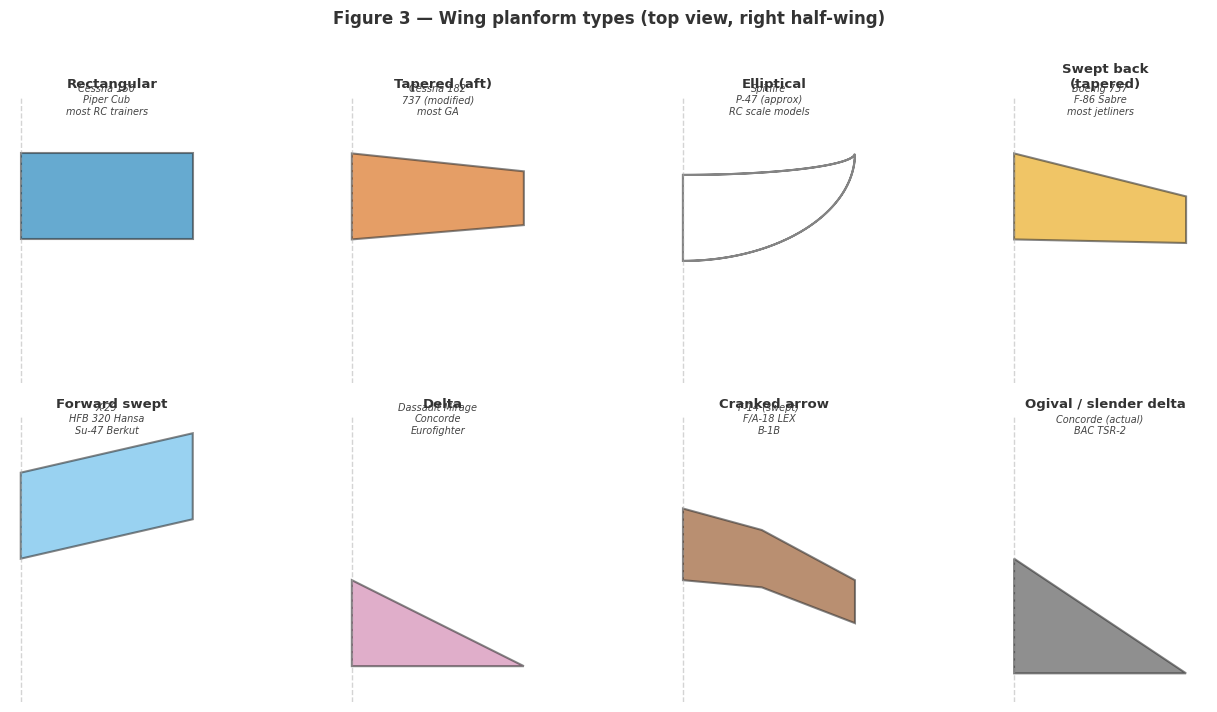

Figure 3 OK


In [4]:

# ── Figure 3: Wing planform shapes (top view, right half-wing) ───────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Figure 3 — Wing planform types (top view, right half-wing)', fontsize=12,
             fontweight='bold', y=1.01)

planforms = [
    # (name, vertices (x=span, y=chord LE/TE), color, examples)
    ('Rectangular',
     [(0,0),(2.4,0),(2.4,-1.2),(0,-1.2)],
     BLUE, 'Cessna 150\nPiper Cub\nmost RC trainers'),
    ('Tapered (aft)',
     [(0,0),(2.4,-0.25),(2.4,-1.0),(0,-1.2)],
     ORANGE, 'Cessna 182\n737 (modified)\nmost GA'),
    ('Elliptical',
     None,  # special case
     GREEN, 'Spitfire\nP-47 (approx)\nRC scale models'),
    ('Swept back\n(tapered)',
     [(0,0),(2.4,-0.6),(2.4,-1.25),(0,-1.2)],
     GOLD, 'Boeing 737\nF-86 Sabre\nmost jetliners'),
    ('Forward swept',
     [(0,0),(2.4,0.55),(2.4,-0.65),(0,-1.2)],
     LBLUE, 'X-29\nHFB 320 Hansa\nSu-47 Berkut'),
    ('Delta',
     [(0,-1.5),(2.4,-2.7),(0,-2.7)],
     PINK, 'Dassault Mirage\nConcorde\nEurofighter'),
    ('Cranked arrow',
     [(0,-0.5),(1.1,-0.8),(2.4,-1.5),(2.4,-2.1),(1.1,-1.6),(0,-1.5)],
     '#8B4513', 'F-14 (swept)\nF/A-18 LEX\nB-1B'),
    ('Ogival / slender delta',
     [(0,-1.2),(2.4,-2.8),(0,-2.8)],
     '#444444', 'Concorde (actual)\nBAC TSR-2'),
]

axes_flat = axes.flatten()
for ax, (name, verts, color, examples) in zip(axes_flat, planforms):
    ax.set_xlim(-0.15, 2.7); ax.set_ylim(-3.2, 0.8)
    ax.set_aspect('equal'); ax.axis('off')

    if name.startswith('Elliptical'):
        # Ellipse: semi-span 2.4, root chord 1.2, tip chord 0
        theta = np.linspace(0, np.pi, 100)
        x_e = 2.4 * np.sin(theta)
        # Chord = root_chord * sqrt(1 - (x/semi_span)^2)
        root_c = 1.2
        chord = root_c * np.sqrt(1 - (x_e/2.4)**2)
        y_le = -chord * 0.25  # LE at 25% of chord from 0 line
        y_te = y_le - chord
        ax.fill(np.append(x_e, x_e[::-1]),
                np.append(y_le, y_te[::-1]),
                color=color, alpha=0.60, edgecolor='#333333', linewidth=1.5)
    else:
        xs = [v[0] for v in verts]
        ys = [v[1] for v in verts]
        ax.fill(xs, ys, color=color, alpha=0.60, edgecolor='#333333', linewidth=1.5)

    # Fuselage centreline
    ax.axvline(0, color='#AAAAAA', linewidth=1.0, linestyle='--', alpha=0.5)

    ax.set_title(name, fontsize=9.5, fontweight='bold')
    ax.text(1.2, 0.55, examples, ha='center', fontsize=7, color='#444', style='italic')

plt.tight_layout()
plt.savefig('fig3_planforms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 OK")


### Rectangular wing

The simplest planform: constant chord from root to tip. The Cessna 150, Piper Cub, and most basic
RC trainer wings are rectangular.

**Full-scale advantages.** Manufacturing cost is low. Ribs are all identical; extrusion tooling
produces one constant-section spar. Stall behaviour with appropriate washout is predictable: the
root stalls before the tip because it operates at slightly higher CL for a given geometric angle
of attack (more precisely, because the tip sees a reduced effective angle of attack from downwash).
A rectangular wing gives the pilot clear buffet warning before full stall.

**Full-scale disadvantages.** Induced drag is higher than for tapered or elliptical wings of the
same span. The rectangular planform loads the wingtip more than optimal, which means more downwash
at the tips, more induced drag. Structural weight is also higher: a constant-chord wing has
significant chord area out near the tip where the loads are lower, wasting material.

**RC advantages.** Identical ribs. A new builder can cut twenty ribs on a single jig in an hour.
No taper angle to misalign. No twist to get wrong. This is why the vast majority of beginner RC
designs use rectangular wings. The stall is also honest and telegraphed.

**RC disadvantages.** Slower than a tapered wing of the same span at the same weight. The tip area
contributes drag without contributing proportional lift benefit.

---

### Tapered wing (aft taper)

The standard GA and transport wing. Root chord is larger than tip chord; typically taper ratio
λ = 0.4–0.6 for GA aircraft. The 737's wing has λ ≈ 0.28 at the tip — quite sharp.

**Full-scale advantages.** Induced drag is significantly lower than rectangular for the same
span. The spanwise lift distribution approaches elliptical for taper ratios around 0.4–0.45. The
spar weight is lower: the spar caps are widest at the root where bending moment is highest and
taper toward the tip. This geometric efficiency is one reason the tapered wing has dominated civil
aircraft since the 1930s {cite}`raymer2018`.

**Full-scale disadvantages.** Tips now experience higher local CL than the root for a given
geometric angle of attack, which means the tip stalls first. Uncontrolled tip stall triggers
aileron loss and violent roll departure. Washout (geometric twist, lower angle of attack at the
tip) is the standard fix, but it adds torsional loading to the structure and reduces the wing's
effective aspect ratio slightly.

**RC advantages.** Looks correct on scale models. Faster than rectangular for the same wing area.
Better glide ratio for a given span. Most intermediate and advanced RC kits use tapered wings.

**RC disadvantages.** Ribs are all different sizes. Tip stall requires careful washout during
construction — a slightly twisted tip can produce an unpredictable snap roll at the stall. Harder
to build accurately than rectangular.

---

### Elliptical wing

The theoretically optimal planform. Minimum induced drag, no taper ratio compromise, perfect
spanwise load distribution. The Supermarine Spitfire used it — along with several other WWII
fighters including the Hawker Hurricane (which used an approximation).

**Full-scale advantages.** For a given span and total lift, an elliptical wing produces the
absolute minimum induced drag. The aerodynamic advantage is real: Spitfire pilots who flew against
the Bf 109 reported that the Spitfire was clearly superior in sustained turn rate below about
400 mph, a direct consequence of its efficient wing {cite}`anderson2012`.

**Full-scale disadvantages.** The manufacturing cost is severe. Every rib is a different shape.
Every spar cap is curved. Supermarine reportedly had significant production difficulties with the
Spitfire wing, and the ellipse was a contributing factor. The P-51 Mustang used a tapered wing
with careful aerodynamic optimisation and nearly matched the Spitfire's lift characteristics at a
fraction of the manufacturing complexity.

**RC advantages.** For a scale Spitfire, you have no choice. The ellipse looks right. Some high-
performance glider designs use approximate ellipses on the outer panels for aerodynamic efficiency.

**RC disadvantages.** Every rib is different. Without CNC cutting tools, accurate construction
is very difficult. Even with CNC it is more expensive than rectangular or tapered. For most RC
applications, a carefully optimised taper is aerodynamically close enough.

---

### Swept-back wing

The leading edge is swept aft of perpendicular to the fuselage centreline, typically 25–45 degrees
for transonic aircraft (737: 25°, F-86: 35°, F-16: 40° at the leading edge root).

**Full-scale advantages.** Sweep raises the critical Mach number — the speed at which local flow
first becomes sonic — by approximately 1/cos(sweep angle). A 35° sweep wing has a critical Mach
roughly 20% higher than the same wing unswept. This is why all jet transports use swept wings: at
Mach 0.85, an unswept wing would be well into wave drag buffet while a 25° swept wing is still
flying cleanly. At supersonic speeds, sweep reduces wave drag directly.

**Full-scale disadvantages.** Swept wings have poor low-speed performance. The spanwise velocity
component carries the boundary layer toward the tip, causing early tip stall. Leading-edge devices
(slats) are almost always necessary on highly swept wings for acceptable approach speeds. The wing
bends and twists under load in a coupled manner — aeroelastic tailoring is needed to prevent tip
washout under gust loads.

**RC advantages.** Swept wings look fast and scale correctly for jet models. They are inherently
stable in pitch (the sweep adds to the apparent dihedral effect) and the swept-back geometry
provides good spiral stability. Many flying-wing-style RC designs use sweep as the primary means
of achieving pitch stability without a tail.

**RC disadvantages.** At low Reynolds numbers (typical of RC aircraft), swept wings lose the
aerodynamic advantages they have at full scale. The boundary layer transition that makes sweep
beneficial at high Reynolds numbers does not occur the same way at low Reynolds numbers. Tip stall
on a swept RC wing can be abrupt and asymmetric. Many RC swept designs add significant washout or
twist to prevent this.

---

### Forward-swept wing

The leading edge sweeps forward — the geometrically opposite configuration to conventional aft
sweep. Examples: Grumman X-29 (1984), HFB 320 Hansa Jet, Sukhoi Su-47 Berkut.

**Full-scale advantages.** On a forward-swept wing, the spanwise velocity component carries the
boundary layer toward the root rather than the tip. This means the root stalls before the tip,
which is the desirable stall progression: the pilot loses some lift but retains aileron authority
as long as the tip is still flying. The X-29 demonstrated excellent post-stall control authority
that aft-swept fighters cannot match {cite}`raymer2018`. The aerodynamic centre also moves
forward, reducing the moment arm that the tail must overcome, in principle allowing a lighter tail.

**Full-scale disadvantages.** Aeroelastic divergence. When a forward-swept wing bends upward, the
leading edge rotates upward too, increasing the local angle of attack, generating more lift, bending
the wing further, increasing the angle of attack further — a positive feedback loop. Without active
structural compensation, this leads to rapid structural failure. The X-29 used anisotropic composite
laminates specifically oriented to introduce a wash-out twist as the wing bent, countering the
divergence. This requires composite manufacturing expertise that adds cost and weight. There has
been no production aircraft with forward sweep since the HFB 320, which used conventional aluminium
and was limited to modest sweep angles precisely because divergence constrained the design.

**RC advantages.** At RC speeds and Reynolds numbers, aeroelastic divergence is not a concern for
rigid-material wings. Forward sweep can give pleasantly honest stall behaviour. Several RC sport
aircraft use forward-swept wings for their unique appearance and handling.

**RC disadvantages.** The appearance is unconventional enough that scale applications are limited.
Without the divergence problem, there is no strong aerodynamic reason to prefer forward sweep over
aft sweep for most RC designs; the benefits are real but subtle at low Reynolds numbers.

---

### Delta wing

The entire wing is a single triangular or near-triangular surface with a very low aspect ratio,
high sweep, and a long root chord. Examples: Dassault Mirage III/F1/2000, Convair F-102, Concorde.

**Full-scale advantages.** The very long root chord gives enormous structural depth, which means a
very stiff, light wing structure. The thin wing has low supersonic wave drag. At high angles of
attack, a delta generates powerful leading-edge vortices that add lift, delaying stall to very high
AoA — Concorde took off at around 16 degrees angle of attack. Internal fuel volume is large.

**Full-scale disadvantages.** Induced drag at low speeds is very high — delta wings need much
higher angles of attack for the same lift as high-aspect-ratio wings, and the wide fuselage shadow
ahead of a classic delta means the field length is long unless carefully managed. Landing speed was
a constant challenge for early delta aircraft: the Mirage III approached at 210 kt because it had
to maintain AoA for lift right until touchdown. The Concorde's droop nose existed precisely because
the pilot could not see over the delta wing nose at landing AoA.

**RC advantages.** Simple construction. One big sheet of foam or balsa with a spar — and you have
a delta. At the speeds RC aircraft fly, the leading-edge vortex lift mechanism is less effective
than at full scale, but the structural simplicity is a genuine benefit. Many foam flying wing
designs are effectively deltas.

**RC disadvantages.** Low-speed handling is sluggish. Landing is fast relative to wing area. If
the CG is not precisely correct, pitch authority is weak because the pitching moment arm is short —
the elevator is at the trailing edge of a wing that has very little moment arm from the leading edge
to the c.g.

```{cite}`raymer2018,anderson2012,sadraey2012`


## 4 — Tail configurations

The tail's job is pitch and yaw stability and control. Its geometry determines how well it does
both — and in some configurations, how catastrophically it fails to do either. The history of
aviation includes several crashes directly attributable to tail configuration choices, which is
why this topic deserves careful attention.


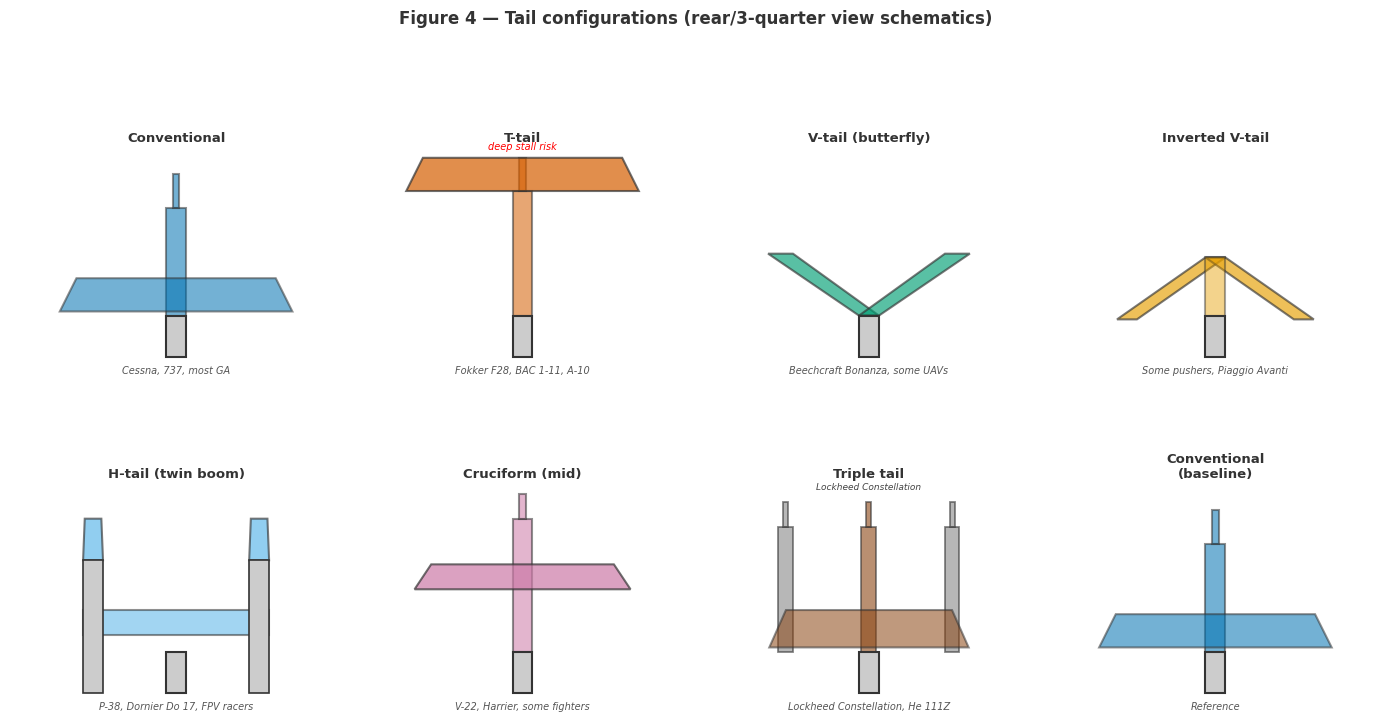

Figure 4 OK


In [5]:

# ── Figure 4: Tail configuration schematics (rear view) ─────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
fig.suptitle('Figure 4 — Tail configurations (rear/3-quarter view schematics)', fontsize=12,
             fontweight='bold', y=1.01)

def draw_tail(ax, config, color, label, example=''):
    ax.set_xlim(-2.0, 2.0); ax.set_ylim(-0.3, 2.5)
    ax.set_aspect('equal'); ax.axis('off')
    # Fuselage stub (centre boom)
    ax.fill([-0.12, 0.12, 0.12, -0.12], [0, 0, 0.5, 0.5],
            color='#CCCCCC', edgecolor='#333', lw=1.5, zorder=2)

    if config == 'conventional':
        # Fin: vertical trapezoid
        ax.fill([-0.12, 0.12, 0.12, -0.12], [0.5, 0.5, 1.8, 1.8],
                color=color, alpha=0.55, edgecolor='#333', lw=1.5)
        ax.fill([-0.04, 0.04, 0.04, -0.04], [1.8, 1.8, 2.2, 2.2],
                color=color, alpha=0.55, edgecolor='#333', lw=1.5)
        # H-stab at low position
        ax.fill([-1.4, 1.4, 1.2, -1.2], [0.55, 0.55, 0.95, 0.95],
                color=color, alpha=0.55, edgecolor='#333', lw=1.5)

    elif config == 'ttail':
        # Fin: tall
        ax.fill([-0.12, 0.12, 0.12, -0.12], [0.5, 0.5, 2.0, 2.0],
                color=color, alpha=0.55, edgecolor='#333', lw=1.5)
        ax.fill([-0.04, 0.04, 0.04, -0.04], [2.0, 2.0, 2.4, 2.4],
                color=color, alpha=0.55, edgecolor='#333', lw=1.5)
        # H-stab at TOP of fin
        ax.fill([-1.4, 1.4, 1.2, -1.2], [2.0, 2.0, 2.4, 2.4],
                color=color, alpha=0.70, edgecolor='#333', lw=1.5)
        ax.text(0, 2.5, 'deep stall risk', ha='center', fontsize=7, color='red', style='italic')

    elif config == 'vtail':
        # Two angled surfaces (V shape)
        angle = 35  # degrees from horizontal
        for sign in [-1, 1]:
            dx = sign * 1.3 * np.cos(np.radians(angle))
            dy = 1.3 * np.sin(np.radians(angle))
            chk = 0.15
            ax.fill([sign*0.12, dx+sign*chk, dx-sign*chk, -sign*0.12],
                    [0.5, 0.5+dy, 0.5+dy, 0.5],
                    color=color, alpha=0.65, edgecolor='#333', lw=1.5)

    elif config == 'inv_vtail':
        # Inverted V
        angle = 35
        for sign in [-1, 1]:
            dx = sign * 1.3 * np.cos(np.radians(angle))
            dy = 1.3 * np.sin(np.radians(angle))
            chk = 0.12
            ax.fill([sign*0.12, dx+sign*chk, dx-sign*chk, -sign*0.12],
                    [1.2, 1.2-dy, 1.2-dy, 1.2],
                    color=color, alpha=0.65, edgecolor='#333', lw=1.5)
        ax.fill([-0.12, 0.12, 0.12, -0.12], [0.5, 0.5, 1.2, 1.2],
                color=color, alpha=0.45, edgecolor='#333', lw=1.5)

    elif config == 'htail':
        # Twin vertical fins on booms, connected by horizontal stab
        for sign in [-1, 1]:
            bx = sign * 1.0
            ax.fill([bx-0.12, bx+0.12, bx+0.12, bx-0.12], [0, 0, 1.6, 1.6],
                    color='#CCCCCC', edgecolor='#333', lw=1.2, zorder=2)
            ax.fill([bx-0.12, bx+0.12, bx+0.1, bx-0.1], [1.6, 1.6, 2.1, 2.1],
                    color=color, alpha=0.65, edgecolor='#333', lw=1.5)
        # H-stab connecting booms
        ax.fill([-1.12, 1.12, 1.12, -1.12], [0.7, 0.7, 1.0, 1.0],
                color=color, alpha=0.55, edgecolor='#333', lw=1.5)

    elif config == 'cruciform':
        # Fin with h-stab midway up
        ax.fill([-0.12, 0.12, 0.12, -0.12], [0.5, 0.5, 2.1, 2.1],
                color=color, alpha=0.55, edgecolor='#333', lw=1.5)
        ax.fill([-0.04, 0.04, 0.04, -0.04], [2.1, 2.1, 2.4, 2.4],
                color=color, alpha=0.55, edgecolor='#333', lw=1.5)
        # H-stab at mid fin
        ax.fill([-1.3, 1.3, 1.1, -1.1], [1.25, 1.25, 1.55, 1.55],
                color=color, alpha=0.70, edgecolor='#333', lw=1.5)

    elif config == 'triple':
        # Three vertical fins
        for bx in [-1.0, 0, 1.0]:
            ax.fill([bx-0.09, bx+0.09, bx+0.09, bx-0.09], [0.5, 0.5, 2.0, 2.0],
                    color=color if bx==0 else GRAY, alpha=0.6, edgecolor='#333', lw=1.3)
            ax.fill([bx-0.03, bx+0.03, bx+0.03, bx-0.03], [2.0, 2.0, 2.3, 2.3],
                    color=color if bx==0 else GRAY, alpha=0.6, edgecolor='#333', lw=1.3)
        ax.fill([-1.2, 1.2, 1.0, -1.0], [0.55, 0.55, 1.0, 1.0],
                color=color, alpha=0.55, edgecolor='#333', lw=1.5)
        ax.text(0, 2.45, 'Lockheed Constellation', ha='center', fontsize=6.5, color='#444',
                style='italic')

    ax.set_title(label, fontsize=9.5, fontweight='bold')
    if example:
        ax.text(0, -0.2, example, ha='center', fontsize=7, color='#555', style='italic')

configs = [
    ('conventional','Conventional',     BLUE,   'Cessna, 737, most GA'),
    ('ttail',       'T-tail',           ORANGE, 'Fokker F28, BAC 1-11, A-10'),
    ('vtail',       'V-tail (butterfly)',GREEN,  'Beechcraft Bonanza, some UAVs'),
    ('inv_vtail',   'Inverted V-tail',  GOLD,   'Some pushers, Piaggio Avanti'),
    ('htail',       'H-tail (twin boom)',LBLUE,  'P-38, Dornier Do 17, FPV racers'),
    ('cruciform',   'Cruciform (mid)',  PINK,   'V-22, Harrier, some fighters'),
    ('triple',      'Triple tail',      '#8B4513','Lockheed Constellation, He 111Z'),
    ('conventional','Conventional\n(baseline)', BLUE, 'Reference'),
]

axes_flat = axes.flatten()
for ax, (cfg, lbl, col, ex) in zip(axes_flat, configs):
    draw_tail(ax, cfg, col, lbl, ex)

plt.tight_layout()
plt.savefig('fig4_tails.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 OK")


### Conventional (low-set horizontal tail)

The horizontal stabiliser sits at or near the base of the vertical fin, well below the wing
wake under all normal flight conditions. This is the configuration used on the overwhelming
majority of aircraft ever built.

**Full-scale advantages.** Simple to design, well-understood structurally, and free of the deep-
stall trap that afflicts T-tails. The horizontal tail sits in relatively undisturbed air, except
in the region directly behind a pusher propeller or a rear-mounted exhaust. Tail volume coefficients
are well-established from decades of empirical data, making initial sizing straightforward.
Elevator linkage routing is simpler than T-tail because the horizontal stab does not sit on top of
a tall, flexible fin.

**Full-scale disadvantages.** On aircraft with low-mounted aft engines (as on some early business
jets), the exhaust plume impinges on the horizontal tail, creating thermal and acoustic fatigue
problems. For propeller aircraft, the slipstream from tractor propellers impinges directly on both
horizontal and vertical surfaces, which increases noise and fatigue loading.

**RC advantages.** Standard, proven, simple. Every RC pilot learns on a conventional tail. Servo
pushrods or control horns run along the fuselage sides to the tail in clean geometry. Fail-safe
is straightforward: if the elevator servo fails neutral, most well-designed RC aircraft with
conventional tails will at least glide rather than pitch abruptly.

**RC disadvantages.** None worth highlighting. The conventional tail is the baseline, and departures
from it require justification.

---

### T-tail

The horizontal stabiliser sits at the top of the vertical fin rather than at its base. Examples:
Fokker F28 Fellowship, BAC 1-11, Vickers VC10, Learjet 23, Cessna Citation CJ series, A-10
Thunderbolt.

**Full-scale advantages.** The horizontal tail is completely clear of the wing wake in cruise,
which improves its aerodynamic efficiency and allows a somewhat smaller surface for the same tail
volume. For rear-mounted engines (which the T-tail was effectively invented to accommodate), this
layout places the horizontal tail well above the engine exhaust. The vertical fin acts as an
endplate for the horizontal stabiliser, increasing its aerodynamic effectiveness.

**Full-scale disadvantages.** Deep stall. This is not a minor concern — it has killed aircraft and
passengers. At high angles of attack (20–30°), the turbulent wing wake can rise to blanket the
horizontal tail completely. With the tail no longer generating any pitching moment, the aircraft
is aerodynamically locked in a stall that no pitch control input can break. Three factors combine:
the T-tail sits directly in the wing-wake region at high AoA; the stall-induced nose-up pitching
moment on many swept-wing aircraft accelerates the pitch-up; and with the engines located behind
the CG (as on T-tailed jets), the loss of lift during the stall causes the nose to pitch up
further. The BAC 1-11 prototype G-ASHG crashed on 22 October 1963 during stall development
testing, killing all seven crew, directly due to deep stall. Development of the type continued
only with a stick pusher and stick shaker system to prevent deep stall entry {cite}`raymer2018`.
The fineness ratio and sweep angle of the wing, the position of aft-mounted engines, and the T-
tail height all interact to determine deep-stall susceptibility. Modern T-tailed aircraft carry
mandatory stick pushers.

**RC advantages.** The T-tail looks correct on scale jets and produces a clean, elegant appearance.
The fin becomes stiffer with the horizontal stab acting as an endplate brace at the top.

**RC disadvantages.** Deep stall at RC scale is usually survivable (the aircraft simply falls to
the ground in a stalled attitude) but represents a genuine loss of control. On foamy trainer jets
where the beginner may allow the model to get slow at high AoA, the T-tail configuration adds
meaningful risk. The structural bending at the horizontal stab attachment at the fin tip is also a
common failure point in RC models — a hard landing that loads the stabiliser transmits a large
moment to the fin.

---

### V-tail (butterfly tail)

Two surfaces set at an angle from the fuselage centreline, typically 30–40° above horizontal, with
no separate fin or horizontal stab. The control surfaces (ruddervators) mix pitch and yaw inputs
simultaneously. The Beechcraft Bonanza is the most famous example; used on 36 Series, V35, and
others since 1947.

**Full-scale advantages.** Fewer surfaces theoretically means lower wetted area. Three surface
junctions (fin-fuselage and two h-stab-fuselage) become one. This was the theoretical justification
for the V-tail on the Bonanza. The interference drag at one junction instead of three should reduce
profile drag.

**Full-scale disadvantages.** The aerodynamic savings are largely illusory. To match a conventional
tail's pitch and yaw authority, the V-tail surfaces must be significantly larger than the theory
suggests, recovering most of the claimed wetted-area advantage. The ruddervator mixing causes roll-
yaw coupling that pilots find unusual — particularly in cross-wind landings, where the simultaneous
application of right rudder and down elevator required in a left cross-wind feels counterintuitive.
The early Bonanza V35 had a structural resonance problem in the tail under certain loading
conditions; the original design required reinforcement after several in-flight structural failures,
which contributed to the Bonanza's (somewhat unfair) reputation for structural fragility
{cite}`raymer2018`. The 36 Series conventional tail Bonanza was introduced partly to address
market perception concerns.

**RC advantages.** V-tails are popular on high-performance sailplanes and FPV UAV designs. The
mixing can be done in the flight controller or in hardware (mechanical Y-mixer). Fewer surfaces
means less drag at low Reynolds numbers, and at RC speeds and scales the coupling problems are
less severe for experienced pilots.

**RC disadvantages.** Beginners find the coupled control unexpected. If the mixer has any phase
error between pitch and yaw, the aircraft rolls on rudder inputs and yaws on elevator inputs —
disorienting in anything other than perfect conditions. Software mixing in a flight controller
introduces the possibility of software failure.

---

### H-tail (twin-boom)

Twin vertical fins connected by a horizontal stabiliser, on twin booms extending aft of the wing.
The Lockheed P-38 Lightning, de Havilland Vampire, Fokker G.1, and most modern long-range UAVs
use this layout.

**Full-scale advantages.** The twin-boom layout allows a pusher propeller at the rear of a central
pod, giving an entirely unobstructed forward hemisphere for the pilot or sensors. The two fins
provide good directional authority and yaw damping; the horizontal stab connecting them benefits
from the endplate effect of both fins simultaneously. For asymmetric propeller aircraft like the
P-38, twin fins also avoid the asymmetric propeller torque problems that afflict single-fin twin-
engine designs.

**Full-scale disadvantages.** Two booms mean two bending beams from wing junction to tail, which
is heavier than a single fuselage of equivalent stiffness. The boom attachment to the wing creates
a complex structural junction. Flutter of the booms has occurred on several H-tail designs.

**RC advantages.** Very popular for FPV long-range fixed-wing designs. Carbon fibre booms are
cheap, light, stiff, and easily replaced after a crash. The pusher layout keeps propwash off a
forward-facing camera. The H-tail provides solid directional control and the configuration is
widely used on racing planes.

**RC disadvantages.** Two fins, two rudder servos, and longer control runs. The boom joints are
common failure points. Boom vibration from the pusher motor reaches the tail surfaces and can
cause control surface flutter at high speeds.

---

### Cruciform tail

The horizontal stabiliser is positioned partway up the vertical fin, roughly at mid-height. Used
where clearance from engine exhaust or rear-ramp blowdown is needed, but without incurring the
full deep-stall risk of a T-tail. Examples: Hawker Harrier, BAe 146, V-22 Osprey.

**Full-scale advantages.** The horizontal stab is above the fuselage wake at normal cruise angles
of attack, improving its efficiency. The deep-stall risk is intermediate between conventional and
T-tail: the wake at high AoA rises partway up the fin, but the elevator retains some authority
because the horizontal stab is not fully immersed in the wing wake. For VTOL aircraft like the
Harrier, this position keeps the tail clear of the engine jet efflux during vertical flight.

**Full-scale disadvantages.** The structural junction at mid-fin is a difficult design point. The
horizontal stab generates a large concentrated bending moment at the junction, which requires heavy
local reinforcement.

**RC advantages.** Used on some scale jet replicas where accuracy to the full-scale design requires
it.

**RC disadvantages.** Structurally awkward. The fin must be reinforced at the horizontal stab
junction, adding weight.

---

### Triple tail

Three vertical fins: one central and one on each tailplane tip. The Lockheed Constellation, Heinkel
He 111Z, and some WWII bombers used this layout.

**Full-scale advantages.** The primary driver for the Constellation's triple tail was hangar height:
a single fin tall enough to provide the necessary area would have exceeded hangar door clearances at
the airports of the late 1940s. Three smaller fins solved the geometry problem without changing the
design brief {cite}`raymer2018`. The triple fin also provides redundancy — partial loss of one fin
still leaves directional control on the other two.

**Full-scale and RC disadvantages.** More surfaces, more junctions, more drag, more complexity.
Absent a specific geometric constraint or requirement, there is no aerodynamic reason to prefer
three fins over one. For RC use, the triple tail appears exclusively on scale models.

```{cite}`raymer2018,sadraey2012,anderson2012`


## 5 — Canard, three-surface, and tandem-wing layouts

A canard is a small horizontal surface placed ahead of the wing rather than behind it. The
distinction sounds minor. Its implications are not.


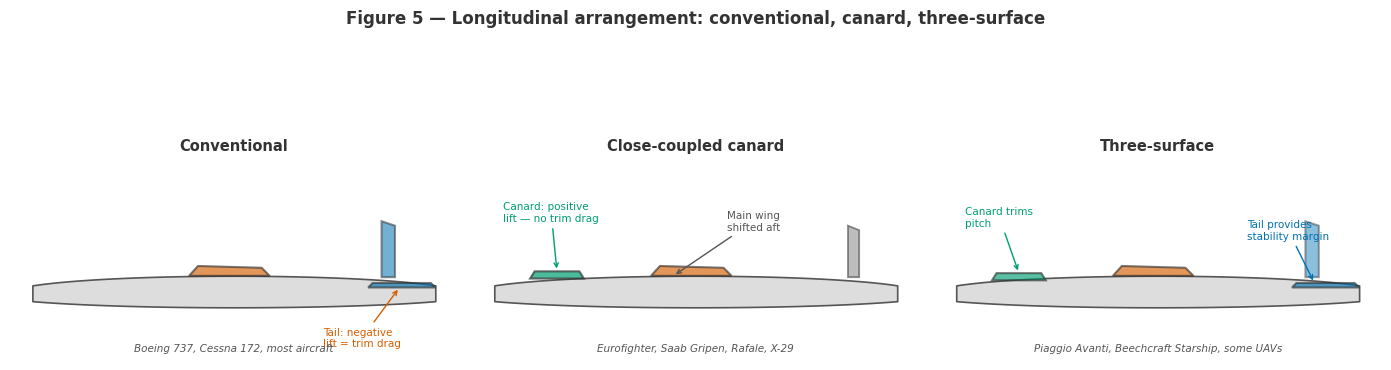

Figure 5 OK


In [6]:

# ── Figure 5: Canard vs conventional vs three-surface (side view) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Figure 5 — Longitudinal arrangement: conventional, canard, three-surface',
             fontsize=12, fontweight='bold', y=1.02)

def draw_side_config(ax, config, title, example):
    ax.set_xlim(-0.5, 9.5); ax.set_ylim(-1.5, 3.0)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=10.5, fontweight='bold', pad=6)

    # Fuselage body
    fus_x = np.linspace(0, 9, 200)
    fus_top = 0.45 * np.sqrt(1 - ((fus_x - 4.5)/5.0)**2) * 0.85
    fus_bot = -0.38 * np.sqrt(1 - ((fus_x - 4.5)/5.5)**2) * 0.85
    ax.fill_between(fus_x, fus_bot, fus_top, color='#DDDDDD', edgecolor='#555', lw=1.2)

    # Main wing (always present, at x=3.5 to 5.5, chord 1.8)
    wc = 1.8  # chord
    wx = 3.5
    ax.fill([wx, wx+wc, wx+wc*0.9, wx+0.2],
            [0.38, 0.38, 0.38+0.18, 0.38+0.22],
            color=ORANGE, alpha=0.65, edgecolor='#333', lw=1.5)

    if config == 'conventional':
        # Aft horizontal tail
        ax.fill([7.5, 9.0, 8.9, 7.6],
                [0.12, 0.12, 0.22, 0.22],
                color=BLUE, alpha=0.65, edgecolor='#333', lw=1.5)
        # Fin
        ax.fill([7.8, 8.1, 8.1, 7.8],
                [0.35, 0.35, 1.5, 1.6],
                color=BLUE, alpha=0.55, edgecolor='#333', lw=1.5)
        ax.annotate('Tail: negative\nlift = trim drag', xy=(8.2, 0.12),
                    xytext=(6.5, -1.2), fontsize=7.5,
                    arrowprops=dict(arrowstyle='->', color='#D55E00'), color='#D55E00')

    elif config == 'canard':
        # Forward canard
        ax.fill([0.8, 2.0, 1.9, 0.9],
                [0.32, 0.32, 0.48, 0.48],
                color=GREEN, alpha=0.70, edgecolor='#333', lw=1.5)
        # Small fin (no aft h-stab)
        ax.fill([7.9, 8.15, 8.15, 7.9],
                [0.35, 0.35, 1.4, 1.5],
                color=GRAY, alpha=0.55, edgecolor='#333', lw=1.3)
        ax.annotate('Canard: positive\nlift — no trim drag', xy=(1.4, 0.48),
                    xytext=(0.2, 1.6), fontsize=7.5,
                    arrowprops=dict(arrowstyle='->', color='#009E73'), color='#009E73')
        ax.annotate('Main wing\nshifted aft', xy=(4.0, 0.38),
                    xytext=(5.2, 1.4), fontsize=7.5,
                    arrowprops=dict(arrowstyle='->', color='#555'), color='#555')

    elif config == 'three_surface':
        # Forward canard
        ax.fill([0.8, 2.0, 1.9, 0.9],
                [0.28, 0.28, 0.44, 0.44],
                color=GREEN, alpha=0.65, edgecolor='#333', lw=1.5)
        # Aft tail
        ax.fill([7.5, 9.0, 8.9, 7.6],
                [0.12, 0.12, 0.22, 0.22],
                color=BLUE, alpha=0.65, edgecolor='#333', lw=1.5)
        # Fin
        ax.fill([7.8, 8.1, 8.1, 7.8],
                [0.35, 0.35, 1.5, 1.6],
                color=BLUE, alpha=0.45, edgecolor='#333', lw=1.5)
        ax.annotate('Canard trims\npitch', xy=(1.4, 0.44),
                    xytext=(0.2, 1.5), fontsize=7.5,
                    arrowprops=dict(arrowstyle='->', color='#009E73'), color='#009E73')
        ax.annotate('Tail provides\nstability margin', xy=(8.0, 0.22),
                    xytext=(6.5, 1.2), fontsize=7.5,
                    arrowprops=dict(arrowstyle='->', color='#0072B2'), color='#0072B2')

    ax.text(4.5, -1.3, example, ha='center', fontsize=7.5, color='#555', style='italic')

draw_side_config(axes[0], 'conventional', 'Conventional',
                 'Boeing 737, Cessna 172, most aircraft')
draw_side_config(axes[1], 'canard', 'Close-coupled canard',
                 'Eurofighter, Saab Gripen, Rafale, X-29')
draw_side_config(axes[2], 'three_surface', 'Three-surface',
                 'Piaggio Avanti, Beechcraft Starship, some UAVs')

plt.tight_layout()
plt.savefig('fig5_canard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 OK")


### Why the canard generates more lift than the conventional tail

A conventional horizontal tail produces *downward* lift to balance the nose-down pitching moment
of the wing. This is the fundamental aerodynamic bargain of conventional design: you pay for
stability with a small constant lift penalty from the tail. The penalty is small in absolute terms
but present on every flight, every hour, for the life of the aircraft.

A canard placed forward of the wing generates *upward* lift when it deflects to trim. The pitching
moment balance still works (positive canard lift × long moment arm = negative pitching moment to
balance wing moment), but now you are adding lift with the canard rather than subtracting it.
This is the primary aerodynamic argument for the canard: trim drag goes to zero in the ideal case.

The catch is that the canard wake impinges directly on the main wing. A canard at high angle of
attack generates downwash that reduces the effective angle of attack of the inboard wing section
behind it. This impairs the wing's ability to generate maximum lift and can, in some configurations,
produce a dangerous pitch-down at high AoA if the main wing reaches maximum lift before the canard
does — because the canard loses its upward lift contribution exactly when the wing needs it most.

**Full-scale advantages.** Used correctly — close-coupled as on the Eurofighter Typhoon — the
canard adds powerful nose-up pitching moments that complement the main wing's aerodynamics in
high-AoA manoeuvres. The combined delta-canard configuration achieves very high instantaneous turn
rates impossible with conventional tail designs. The canard stalls before the main wing (if
designed correctly), giving automatic stall protection: the aircraft pitches down before the main
wing stalls. There is no risk of deep stall because the nose drops when the canard stalls.

**Full-scale disadvantages.** The CG range is tighter than for a conventional aircraft — the
moment arm geometry leaves less room for CG movement. Full-span flaps on the main wing are difficult
because they shift the aerodynamic centre aft and change the pitch trim requirement significantly.
Fighters with canards (Gripen, Typhoon, Rafale) are all fly-by-wire with active control laws to
manage canard-wing interaction {cite}`sadraey2012`. For civil transport applications, the Beechcraft
Starship demonstrated that a canard-equipped transport is achievable, but the design complexity
and certification challenges are substantial.

**RC advantages.** Canard RC aircraft are very resistant to deep stall and classic departure stalls.
The auto-recovery tendency — nose drops before wing stall — makes them forgiving in gusty
conditions. Several long-range FPV designs (SonicModell AR Wing Pro, Zeta FX-61) use canard or
three-surface layouts.

**RC disadvantages.** CG placement is critical and counterintuitive. New pilots expect to add nose
weight to fix a nose-high trim, which works on a conventional aircraft. On a canard aircraft,
moving the CG forward can make the pitch stability worse because the canard's restoring moment
depends on the CG being aft of the canard's aerodynamic centre. Getting it wrong produces an
aircraft that pitches abruptly in either direction and is essentially uncontrollable.

---

### Three-surface layout

Canard ahead of the main wing AND a conventional tail surface behind it — three lifting surfaces
total. The Piaggio P.180 Avanti uses this layout; Rutan explored several three-surface designs.

**Full-scale advantages.** The canard can be used to add lift (reducing induced drag) while the
conventional tail provides the stability margin that a pure canard configuration lacks. Wing loading
is reduced. The configuration has a wider CG range than a pure canard because the aft tail provides
a conventional stability guarantee. This is why the Avanti — a high-speed business turboprop that
must be usable by non-specialist pilots — chose three surfaces rather than pure canard.

**Full-scale disadvantages.** Three lifting surfaces are three interference drag problems, three
structural attachment points, three control systems to integrate. The aerodynamic advantage over
a conventional design is real but modest. The certification programme for the Avanti was long
partly because of the novelty of the configuration.

**RC advantages.** RC three-surface designs are unusual but not unheard of. They can provide a
wide CG range that accommodates variable battery position.

**RC disadvantages.** Complexity. Three control surfaces require three servos and careful mixer
programming to avoid pitching interference between the canard and elevator.

```{cite}`raymer2018,sadraey2012,torenbeek2013`


## 6 — Flying wing and blended wing-body (BWB)

The flying wing eliminates the fuselage and tail entirely. Everything — lift, payload, stability,
control — comes from a single surface. The promise is extraordinary: no fuselage drag, no tail
drag, every kilogram of structure contributing to lift rather than just holding the aircraft
together. The reality is more complicated.


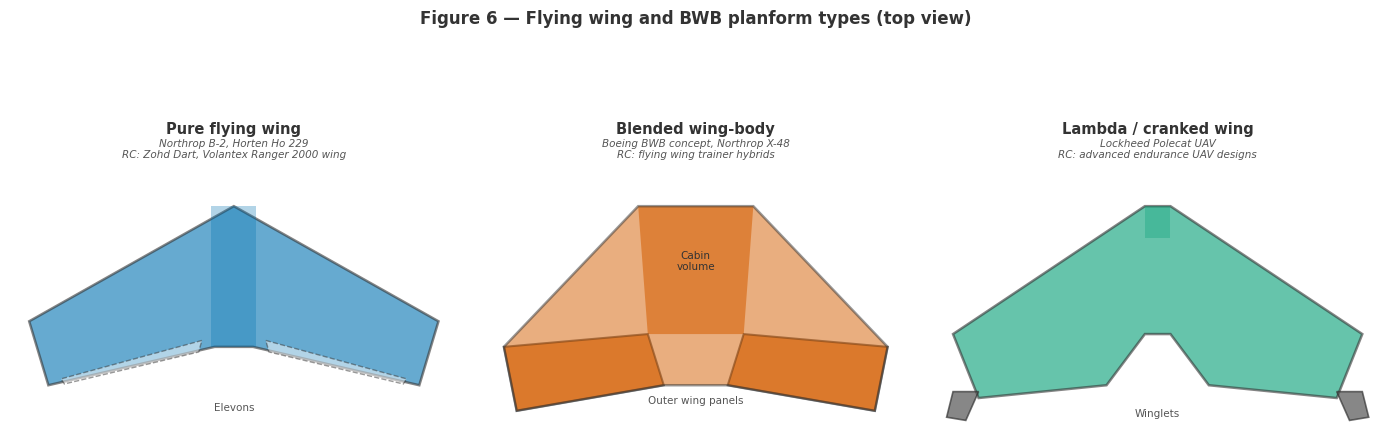

Figure 6 OK


In [7]:

# ── Figure 6: Flying wing planform types (top view) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Figure 6 — Flying wing and BWB planform types (top view)', fontsize=12,
             fontweight='bold', y=1.02)

def draw_fw(ax, fw_type, title, color, example):
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 1.0)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=10.5, fontweight='bold', pad=6)

    if fw_type == 'pure_fw':
        # Swept flying wing — B-2 style
        # Right half: LE swept at ~33 deg, TE swept at ~33 deg
        pts_right = [(0, 0), (3.2, -1.8), (2.9, -2.8), (0.3, -2.2)]
        pts_left  = [(-x, y) for x,y in pts_right]
        all_pts   = pts_right + list(reversed(pts_left))
        xs = [p[0] for p in all_pts]
        ys = [p[1] for p in all_pts]
        ax.fill(xs, ys, color=color, alpha=0.60, edgecolor='#333', lw=1.8)
        # Centerline body blending
        ax.fill([-0.35, 0.35, 0.35, -0.35], [0, 0, -2.2, -2.2],
                color=color, alpha=0.30, edgecolor='none')
        # Elevons shown as lighter strip along TE
        ax.fill([0.5, 2.7, 2.65, 0.55], [-2.1, -2.7, -2.78, -2.28],
                color='white', alpha=0.5, edgecolor='#333', lw=1, linestyle='--')
        ax.fill([-0.5, -2.7, -2.65, -0.55], [-2.1, -2.7, -2.78, -2.28],
                color='white', alpha=0.5, edgecolor='#333', lw=1, linestyle='--')
        ax.text(0, -3.2, 'Elevons', ha='center', fontsize=7.5, color='#555')

    elif fw_type == 'bwb':
        # BWB: wide centre body blending into wings
        # Centre body
        ax.fill([-0.9, 0.9, 0.75, -0.75], [0, 0, -2.0, -2.0],
                color=color, alpha=0.55, edgecolor='none')
        # Outer wings
        pts_r = [(0.75, -2.0), (3.0, -2.2), (2.8, -3.2), (0.5, -2.8)]
        pts_l = [(-x, y) for x,y in pts_r]
        ax.fill([p[0] for p in pts_r], [p[1] for p in pts_r],
                color=color, alpha=0.65, edgecolor='#333', lw=1.5)
        ax.fill([p[0] for p in pts_l], [p[1] for p in pts_l],
                color=color, alpha=0.65, edgecolor='#333', lw=1.5)
        # Smooth centre-to-wing fairing
        # Draw as one polygon
        all_pts = ([(-0.9, 0), (0.9, 0), (3.0, -2.2), (2.8, -3.2),
                    (0.5, -2.8), (-0.5, -2.8), (-2.8, -3.2), (-3.0, -2.2)])
        ax.fill([p[0] for p in all_pts], [p[1] for p in all_pts],
                color=color, alpha=0.50, edgecolor='#333', lw=1.8)
        ax.text(0, -1.0, 'Cabin\nvolume', ha='center', fontsize=7.5, color='#333')
        ax.text(0, -3.1, 'Outer wing panels', ha='center', fontsize=7.5, color='#555')

    elif fw_type == 'lambda':
        # Lambda/cranked arrow wing
        pts_r = [(0.2, 0), (3.2, -2.0), (2.8, -3.0), (0.8, -2.8), (0.2, -2.0)]
        pts_l = [(-x, y) for x,y in pts_r]
        all_pts = pts_r + list(reversed(pts_l))
        ax.fill([p[0] for p in all_pts], [p[1] for p in all_pts],
                color=color, alpha=0.60, edgecolor='#333', lw=1.8)
        # Notch at centre leading edge
        ax.fill([-0.2, 0.2, 0.2, -0.2], [0, 0, -0.5, -0.5],
                color=color, alpha=0.3, edgecolor='none')
        # Winglets
        for sign in [-1, 1]:
            ax.fill([sign*2.8, sign*3.2, sign*3.3, sign*3.0],
                    [-2.9, -2.9, -3.3, -3.35],
                    color='#555', alpha=0.7, edgecolor='#333', lw=1.2)
        ax.text(0, -3.3, 'Winglets', ha='center', fontsize=7.5, color='#555')

    ax.text(0, 0.75, example, ha='center', fontsize=7.5, color='#555', style='italic')

draw_fw(axes[0], 'pure_fw',  'Pure flying wing',    BLUE,   'Northrop B-2, Horten Ho 229\nRC: Zohd Dart, Volantex Ranger 2000 wing')
draw_fw(axes[1], 'bwb',      'Blended wing-body',   ORANGE, 'Boeing BWB concept, Northrop X-48\nRC: flying wing trainer hybrids')
draw_fw(axes[2], 'lambda',   'Lambda / cranked wing',GREEN,  'Lockheed Polecat UAV\nRC: advanced endurance UAV designs')

plt.tight_layout()
plt.savefig('fig6_flying_wing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 OK")


### Pure flying wing

No fuselage. No tail. The payload sits inside the wing centre section. Northrop built flying wings
from the 1940s (N-1M, YB-35) through the B-2 Spirit (first flight 1989), which remains the
only large operational flying wing in service.

**Full-scale advantages.** The absence of a fuselage and tail eliminates roughly 40% of a
conventional aircraft's profile drag sources. Every wetted area generates lift rather than drag or
structural ballast. Internal volume for fuel and payload is significant: the B-2's centre section
accommodates 75,000 lb of fuel and two weapon bays within a wing of 172 ft span. Low radar cross-
section is a direct result of the smooth continuous surface with no vertical tail, no engine nacelle
projections, and no fuselage discontinuities — the LO shaping advantage of the flying wing is not
a coincidence, it is a direct consequence of the configuration's geometry {cite}`raymer2018`.

**Full-scale disadvantages.** Pitch stability with a short moment arm. The elevator (elevon)
deflection must produce large pitching moments from a small moment arm (the distance from the
aerodynamic centre to the elevon), which requires large surfaces and generates significant induced
drag from the trim condition. Longitudinal stability requires reflex camber or geometric wash-out
along the span: the trailing-edge section must curve upward to generate a natural nose-down pitching
moment. This reflexed camber reduces maximum CL, penalising low-speed performance.

Yaw control without a fin is the other fundamental problem. The B-2 uses split drag rudders
(clamshell devices at the wingtips) and differential thrust for yaw control. Yaw damping is
inherently low without a fin, making Dutch roll a more severe dynamic problem than on conventional
aircraft — the B-2 fly-by-wire system actively damps this mode. Without active control, flying
wings are difficult or impossible to fly in turbulence. The Horten brothers' wartime Ho 229
prototype was unstable enough in yaw that even experienced test pilots found it demanding.

The CG range is extremely tight. Moving payload aft of design position can make the aircraft
longitudinally unstable; moving it forward makes pitch authority inadequate for rotation on takeoff.

**RC advantages.** Flying wings are one of the most popular RC designs in the hobby. The geometry
is simple — a single surface, no fuselage to build, no tail to align. A foam sheet and a spar is
enough to fly. The Z-84, Zohd Dart, Volantex Ranger 2000 wing, and Flite Test Simple Soarer are
all derivatives of this basic idea. The flying wing is efficient at RC scale: it can achieve
excellent glide ratios with modest motor power and carry FPV cameras with clean forward views.

**RC disadvantages.** CG placement is unforgiving. Manufacturers specify a CG range of perhaps
±3–5 mm on a 500 mm mean chord wing — a 1% variation that will make the difference between a
perfectly flying model and an aircraft that pitches violently in both directions. Battery
placement is the primary CG adjustment mechanism: moving a 200g battery 10 mm fore or aft
can shift the CG enough to change the flying characteristics fundamentally. A new builder who
follows the instructions gets a good-flying model; one who improvises battery placement can easily
build an uncontrollable one.

Pitch authority at low speeds is modest because the elevons are close to the aerodynamic centre.
This means the stall can be abrupt in some designs, and the flare on landing must be timed
carefully. Unlike a conventional aircraft, where you simply pull back progressively to land, a
flying wing often requires a precise pitch input at a specific speed.

---

### Blended wing-body (BWB)

The BWB blurs the boundary between wing and fuselage: the centre section is wide enough to carry
passengers or cargo, and it blends continuously into outer wing panels without a clear junction.
Boeing's BWB concept (studied through the X-48 demonstrator programme) and Airbus's recent concept
aircraft are the leading examples.

**Full-scale advantages.** All the aerodynamic advantages of the flying wing, plus a usable payload
volume in the wide centre section. Structural efficiency is high because the lift is generated along
the entire span including the centre body, not concentrated at a separate wing attachment. The wide
pressure vessel cross-section is actually more efficient than a circular fuselage at very large
diameters. A 1992 McDonnell Douglas study found that a 800-passenger BWB transport could achieve
roughly 27% lower fuel burn than a conventional tube-and-wing aircraft of the same capacity
{cite}`torenbeek2013`.

**Full-scale disadvantages.** The passenger cabin sits inside a non-cylindrical pressure vessel,
raising certification questions about emergency evacuation. Passengers seated in the outer sections
have no window and are far from the exits. At narrow body scale (less than about 400 passengers),
the BWB's aerodynamic advantage largely disappears — the centre body becomes disproportionately
large relative to the wing panels, and the wetted-area advantage shrinks. Every BWB analysis
consistently concludes the same thing: this configuration only pays off at very large scale, which
is why no BWB has entered production in 80 years of study {cite}`torenbeek2013`.

**RC advantages.** BWB-style flying wings with a thickened centre section are increasingly popular
as FPV carriers: the centre section provides space for electronics, FPV equipment, and batteries
without the CG sensitivity of a pure flying wing, because the thicker centre section allows more
CG range.

**RC disadvantages.** Manufacturing a smooth blend between centre section and outer wing requires
either precision moulding or patient hand-shaping. Many RC designs approximate the blend with a
straight step fairing, which is aerodynamically crude but adequate for the speeds involved.

```{cite}`raymer2018,torenbeek2013,sadraey2012`


## References

```{bibliography}
:filter: docname in docnames
```
